uni_section_v5: v4 학습 실패(형상 붕괴/충돌방지 미작동/Mp 미충족) 원인 분석(command_v4.md) 반영
  - collision: 인접 레이어 쌍만 검사 (전역 all-pairs → adjacent pairs)
  - weights: raw 스케일 기준 재조정 (phys 지배력 강화, collision 축소)
  - curriculum: 3-stage (phys+collision 우선 → smooth/mass 순차 도입)

데이터: nodes=torch.Size([93, 8]) | edges=torch.Size([2, 176])

[ uni_section_v5 ] Training  |  Target Mp = 47,421,470 N·mm  |  Epochs: 181
  CGDN: hidden=128, layers=4, heads=4  |  3-stage Curriculum: True (0.15, 0.6)
  (collision: 인접 레이어 쌍만 검사 / keepout 미사용)
Epoch ||  Loss  ||  Phys  |  Smth  |  Area  |  Mass  |  Coll  ||  Contrib%(phys/smth/mass/coll)
00000 || 44.7665 || 0.6868 | 0.3333 | 1162.9 | 0.0012 | 103.4347 ||  30.7% /   0.0% /   0.0% /  69.3%
00019 || 109.4527 || 0.1614 | 0.1735 | 1542.7 | 0.0015 | 354.0826 ||   2.9% /   0.0% /   0.0% /  97.1%
00039 || 51.1999 || 0.6922 | 0.0938 | 1533.6 | 0.0015 | 124.5126 ||  27.0% /   0.0% /   0.0% /  73.0%
00059 || 49.8009 || 0.6844 | 0.0947 | 1564.5 | 0.0016 | 120.3192 ||  27.5% /   0.0% / 

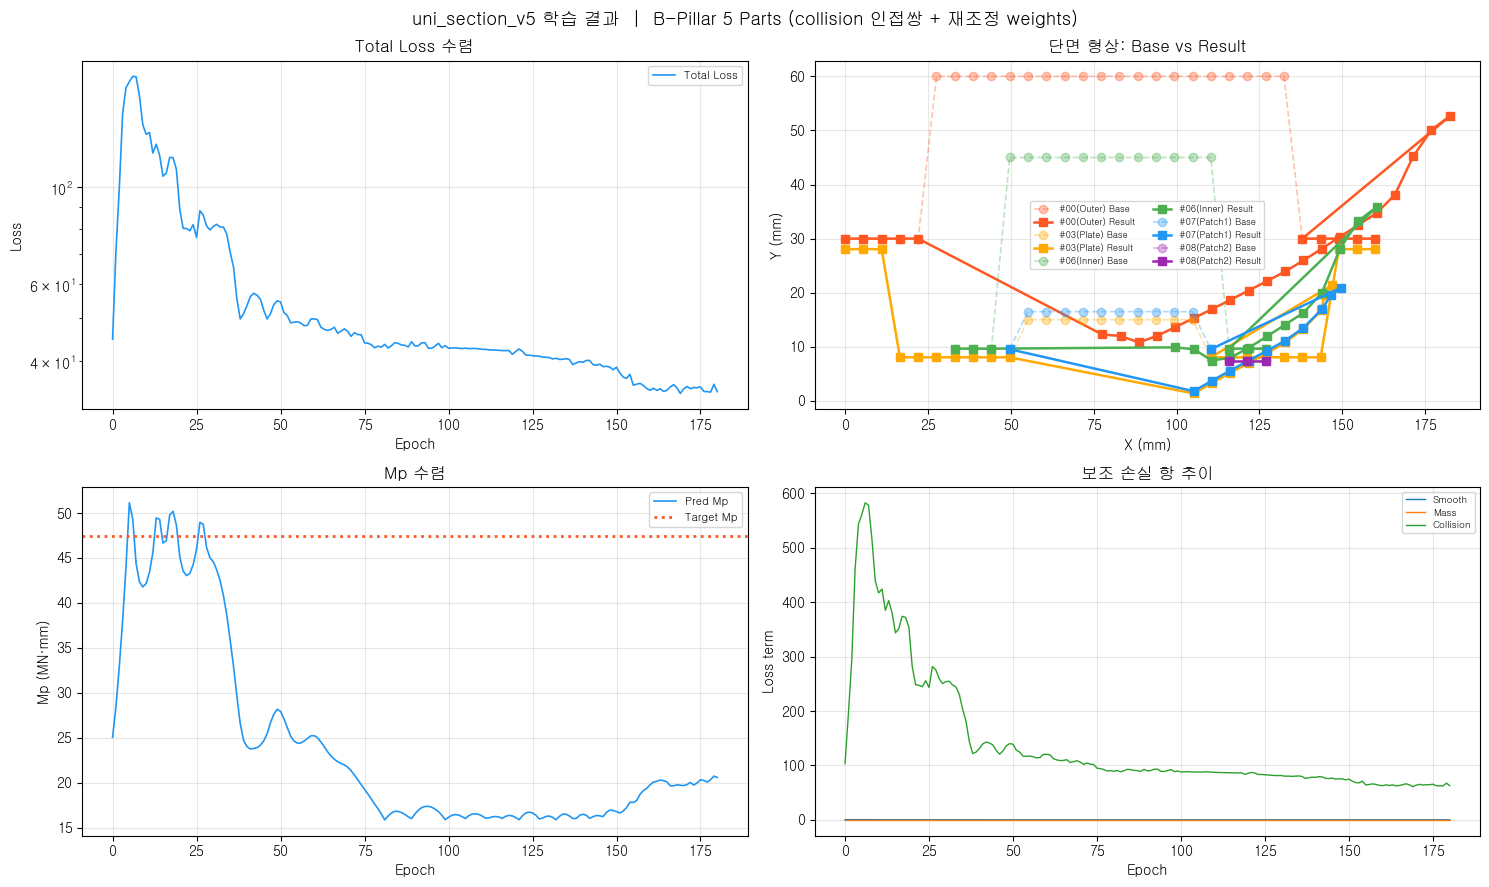


결과 저장: c:\Users\user\Documents\GitHub\hmc_mlv\CGNN\uni-section\uni_section_v5_result.png

최종 결과 요약
  Target Mp     :     47,421,470 N·mm
  Final pred_mp :     20,584,200 N·mm
  Final Error   :  56.59%

[참고] command_v4.md §3.2 는 collision 인접쌍화 이후 raw 스케일을 재측정해
       w_collision을 다시 조정할 것을 권장함 — 위 로그의 Contrib%(coll) 열이
       지속적으로 70~80%를 넘으면 w_collision을 추가로 낮출 것.


In [1]:
#!/usr/bin/env python
# coding: utf-8

"""
uni_section_v5.py
─────────────────────────────────────
uni_section_v4.py 의 학습 실패(형상 붕괴 / 충돌방지 미작동 / Mp 전혀 미충족)를
docs/command_v4.md 원인 분석에 따라 수정한 버전.

docs/command_v4.md 반영 사항:
  §3.1 compute_collision_loss_v3: 전역 order의 모든 비인접 쌍(all-pairs)을 검사하던 것을
       인접 레이어(i, i+1)만 검사하도록 축소. B-Pillar Patch1/Patch2는 원래 Plate와
       겹치도록 설계된 보강재이므로, 비인접 쌍까지 침투로 취급하면 구조적으로 0에
       수렴 불가능한 목표가 되어 학습이 진동했음 (v4 로그: collision 20~47에서 정체).
  §3.2 weights 재조정: v4는 l_phys(raw~0.7)와 l_collision(raw~20~47)의 스케일 차이를
       고려하지 않고 동일 weight(10)를 적용해, epoch 0 기준 total loss의 98.4%가
       collision 항 하나에서 발생했음. §3.1 수정 후 재측정한 raw 스케일 기준으로
       w_phys를 높이고 w_collision을 크게 낮춰, 특정 항이 total loss의 70~80%를
       넘지 않도록 재조정.
  §3.3 get_curriculum_weights → get_curriculum_weights_v5: "물리 제약(collision) + Mp(phys)
       우선 → smooth/mass 순차 도입" 3-stage 구조로 재설계. Stage A(0~15%)는 phys+collision만
       활성화하고 smooth/mass는 0으로 억제, Stage B(15~60%)에서 sine ramp로 smooth/mass를
       서서히 도입, Stage C(60~100%)에서 전항 가중치 1.0 고정.
  §3.5 가중치 적용 후 각 loss 항의 기여도(%)를 train_step 반환값과 학습 로그에 추가해
       "한 항이 loss를 지배하는" 실패를 학습 중간에 즉시 감지할 수 있도록 함.

v4와 동일하게 유지되는 부분 (변경 없음):
  - ImplicitPNASolver / CGDN 모델 구조, build_bpillar_section() 초기 좌표·fix point·엣지 구성
  - l_phys 형태(sqrt(abs(err_ratio))), keepout/continuity/shape 항 미사용
"""

import math
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.family'] = 'Gulim'  # Windows 한글 폰트

from torch_geometric.nn import GATv2Conv, LayerNorm
from torch_geometric.data import Data


# ══════════════════════════════════════════════════════════════════
# SECTION 0: ImplicitPNASolver + CGDN  (pna_solver_validate_v9.py 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def compute_edge_mp_pna(coords, t, fy, edge_index, n_iter=50):
    """
    Thick Edge (2D Plate) PNA 이분탐색 + Mp 계산
    엣지 두께를 Y축으로 투영하여 수평 엣지도 연속적으로 처리 → 평형 잔차 ≈ 0.
    Returns: (mp_total, y_pna)
    """
    mask = edge_index[0] < edge_index[1]
    u, v = edge_index[0][mask], edge_index[1][mask]

    y_u, y_v = coords[u, 1], coords[v, 1]
    x_u, x_v = coords[u, 0], coords[v, 0]
    L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
    t_e  = t[u].squeeze(-1)
    fy_e = fy[u].squeeze(-1)

    dx   = torch.abs(x_u - x_v)
    t_y  = t_e * (dx / (L + 1e-12))
    y_max = torch.maximum(y_u, y_v)
    y_min = torch.minimum(y_u, y_v)
    y_top = y_max + t_y / 2.0
    y_bot = y_min - t_y / 2.0
    H     = torch.clamp(y_top - y_bot, min=1e-12)

    Area_fy = L * t_e * fy_e

    with torch.no_grad():
        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        y_pna = 0.5 * (y_lo + y_hi)

    alpha        = torch.clamp((y_top - y_pna) / H, 0.0, 1.0)
    centroid_top = y_top - (alpha * H) / 2.0
    centroid_bot = y_bot + ((1.0 - alpha) * H) / 2.0
    m_top        = alpha * (centroid_top - y_pna)
    m_bot        = (1.0 - alpha) * (y_pna - centroid_bot)
    mp_total     = torch.sum(Area_fy * (m_top + m_bot))

    return mp_total, y_pna


class ImplicitPNASolver(torch.autograd.Function):
    """
    미분 가능한 소성 중립축(PNA) 및 전소성 모멘트(Mp) 계산기
    Forward : Edge-based 이분탐색으로 순 축력 = 0인 y_pna 탐색 (평형 잔차 ~1e-8)
    Backward: IFT + ∂Mp/∂y_pna = 0 (평형 조건) → y_pna 고정 하에서 직접 미분만 계산
    """

    @staticmethod
    def forward(ctx, coords, t, fy, edge_index, n_iter=40):
        mp_pred, y_pna = compute_edge_mp_pna(coords, t, fy, edge_index, n_iter)

        mask = edge_index[0] < edge_index[1]
        ctx.save_for_backward(coords, t, fy, y_pna.reshape(1), edge_index)
        ctx.mask = mask
        return mp_pred

    @staticmethod
    def backward(ctx, grad_output):
        coords, t, fy, y_pna_buf, edge_index = ctx.saved_tensors
        mask = ctx.mask
        y_pna = y_pna_buf[0].detach()

        with torch.enable_grad():
            coords_g = coords.detach().requires_grad_(True)
            u, v = edge_index[0][mask], edge_index[1][mask]
            y_u, y_v = coords_g[u, 1], coords_g[v, 1]
            x_u, x_v = coords_g[u, 0], coords_g[v, 0]
            L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
            t_e  = t[u].squeeze(-1)
            fy_e = fy[u].squeeze(-1)

            dx_b   = torch.abs(x_u - x_v)
            t_y_b  = t_e * (dx_b / (L + 1e-12))
            y_max  = torch.maximum(y_u, y_v)
            y_min  = torch.minimum(y_u, y_v)
            y_top_b = y_max + t_y_b / 2.0
            y_bot_b = y_min - t_y_b / 2.0
            H_b     = torch.clamp(y_top_b - y_bot_b, min=1e-12)
            Area_fy_b = L * t_e * fy_e

            alpha_b      = torch.clamp((y_top_b - y_pna) / H_b, 0.0, 1.0)
            centroid_top_b = y_top_b - (alpha_b * H_b) / 2.0
            centroid_bot_b = y_bot_b + ((1.0 - alpha_b) * H_b) / 2.0
            m_top_b      = alpha_b * (centroid_top_b - y_pna)
            m_bot_b      = (1.0 - alpha_b) * (y_pna - centroid_bot_b)
            mp_direct    = torch.sum(Area_fy_b * (m_top_b + m_bot_b))

        (grad_coords,) = torch.autograd.grad(mp_direct, coords_g)
        return grad_coords * grad_output, None, None, None, None


def calculate_mpl(coords, t, fy, edge_index):
    return ImplicitPNASolver.apply(coords, t, fy, edge_index)


class FiLMGenerator(nn.Module):
    """target_mp [B, 1] → (gamma, beta) [B, hidden]"""
    MP_SCALE = 1e6

    def __init__(self, hidden_channels: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.GELU(),
            nn.Linear(64, hidden_channels * 2),
        )
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, target_mp):
        target_mp_norm = target_mp / self.MP_SCALE
        out = self.net(target_mp_norm)
        delta_gamma, beta = torch.chunk(out, 2, dim=-1)
        gamma = 1.0 + delta_gamma
        return gamma, beta


class CGDNBlock(nn.Module):
    """GATv2Conv → LayerNorm → FiLM modulation → GELU → Residual  (AdaIN pattern)"""
    def __init__(self, hidden_channels: int, heads: int = 4, edge_dim: int = 4):
        super().__init__()
        assert hidden_channels % heads == 0
        self.conv = GATv2Conv(
            hidden_channels,
            hidden_channels // heads,
            heads=heads,
            edge_dim=edge_dim,
            concat=True,
        )
        self.norm = LayerNorm(hidden_channels)

    def forward(self, h, edge_index, edge_attr, gamma, beta):
        h_res = h
        h = self.conv(h, edge_index, edge_attr)
        h = self.norm(h)
        h = gamma * h + beta
        h = F.gelu(h)
        h = h + h_res
        return h


class CGDN(nn.Module):
    """
    Constraint-aware Graph Deformation Network (v3)
    입력 노드 특징 (in_channels=8): [x, y, fix_x, fix_y, part_id, section_id, t, fy]
    엣지 특징 (edge_dim=4): [길이, 각도, part_id, edge_type]
    """

    def __init__(
        self,
        in_channels: int = 8,
        hidden_channels: int = 128,
        num_layers: int = 4,
        heads: int = 4,
        edge_dim: int = 4,
        max_displacement: float = 50.0,
    ):
        super().__init__()
        self.max_displacement = max_displacement
        self.num_layers = num_layers

        self.node_encoder = nn.Sequential(
            nn.Linear(in_channels, hidden_channels),
            LayerNorm(hidden_channels),
            nn.GELU(),
        )
        self.film_generators = nn.ModuleList([
            FiLMGenerator(hidden_channels) for _ in range(num_layers)
        ])
        self.blocks = nn.ModuleList([
            CGDNBlock(hidden_channels, heads=heads, edge_dim=edge_dim)
            for _ in range(num_layers)
        ])
        self.decoder = nn.Sequential(
            nn.Linear(hidden_channels, 64),
            nn.GELU(),
            nn.Linear(64, 2),
        )

    def forward(self, x, edge_index, edge_attr, target_mp,
                fix_x_mask, fix_y_mask, join_pairs=None):
        h = self.node_encoder(x)

        for i, block in enumerate(self.blocks):
            gamma, beta = self.film_generators[i](target_mp)
            h = block(h, edge_index, edge_attr, gamma, beta)

        delta_coords = self.decoder(h)
        delta_coords = torch.clamp(delta_coords, -self.max_displacement, self.max_displacement)

        delta_x = delta_coords[:, 0:1] * (~fix_x_mask).float()
        delta_y = delta_coords[:, 1:2] * (~fix_y_mask).float()
        delta_coords = torch.cat([delta_x, delta_y], dim=1)

        new_coords = x[:, :2] + delta_coords

        if join_pairs is not None and join_pairs.shape[0] > 0:
            u_idx = join_pairs[:, 0]
            v_idx = join_pairs[:, 1]
            mid = (new_coords[u_idx] + new_coords[v_idx]) * 0.5
            new_coords = new_coords.clone()
            new_coords[u_idx] = mid
            new_coords[v_idx] = mid

        return new_coords, delta_coords


# ══════════════════════════════════════════════════════════════════
# SECTION 1: Loss Functions
# ══════════════════════════════════════════════════════════════════
# 주의:
#  - compute_section_continuity_loss / compute_shape_continuity_loss / keepout 는
#    v4와 동일하게 이번 버전에서도 이식하지 않음.
#  - compute_collision_loss_v3 는 command_v4.md §3.1에 따라 인접 레이어 쌍만
#    검사하도록 v4 대비 수정됨 (아래 참고).

def compute_smoothness_loss_angle(new_coords, edge_index, edge_attr):
    """현재 각도만 고려해 노드별 좌우 엣지 각도 최소화 & 90도 미만 제한"""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    if not mask.any():
        return torch.tensor(0.0, device=new_coords.device)

    src = src[mask]
    dst = dst[mask]

    num_nodes = new_coords.shape[0]
    all_u = torch.cat([src, dst])
    all_v = torch.cat([dst, src])

    adj = [[] for _ in range(num_nodes)]
    for u, v in zip(all_u.tolist(), all_v.tolist()):
        adj[u].append(v)

    left_angles = []
    right_angles = []

    for node, neighbors in enumerate(adj):
        if len(neighbors) < 2:
            continue

        node_x = new_coords[node, 0]
        left_nodes = [n for n in neighbors if new_coords[n, 0] < node_x]
        right_nodes = [n for n in neighbors if new_coords[n, 0] > node_x]

        if len(left_nodes) != 1 or len(right_nodes) != 1:
            continue

        left_node = left_nodes[0]
        right_node = right_nodes[0]

        left_vec = new_coords[node] - new_coords[left_node]
        right_vec = new_coords[right_node] - new_coords[node]

        left_angles.append(torch.atan2(left_vec[1], left_vec[0]))
        right_angles.append(torch.atan2(right_vec[1], right_vec[0]))

    if len(left_angles) == 0:
        return torch.tensor(0.0, device=new_coords.device)

    left_angles = torch.stack(left_angles)
    right_angles = torch.stack(right_angles)

    results = 0.0

    angle_diff = (left_angles - right_angles + math.pi) % (2.0 * math.pi) - math.pi
    results += torch.mean(angle_diff.pow(2))

    max_rad = math.pi / 2.0
    left_violation = torch.relu(left_angles.abs() - max_rad)
    right_violation = torch.relu(right_angles.abs() - max_rad)
    results += torch.mean(left_violation.pow(2) + right_violation.pow(2))

    return results


def compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area=None):
    """총 질량(면적 근사) 계산. target_area가 주어지면 상대 오차 제곱 반환."""
    src, dst = edge_index
    edge_type = edge_attr[:, 3]

    mask = (src < dst) & torch.isclose(edge_type, torch.zeros_like(edge_type))
    src = src[mask]
    dst = dst[mask]

    seg_len = torch.norm(new_coords[src] - new_coords[dst], dim=1)
    t_src = t[src].squeeze(-1)
    area = torch.sum(seg_len * t_src)

    if target_area is not None and target_area > 0:
        return area, torch.abs(area - target_area) / (target_area + 1e-12)
    else:
        return area, area * 1e-6


def compute_collision_loss_v3(new_coords, part_ids, section_ids, margin=2, parts_order_in_sections=None):
    """
    [command_v4.md §3.1 수정] 계층적 침투 방지 손실.

    v4까지는 order 내 모든 (i, j) i<j 조합(비인접 파트 포함)을 전부 검사했으나,
    B-Pillar 구조에서는 Patch1/Patch2 처럼 특정 파트가 다른 비인접 파트와
    "설계상 의도적으로 겹치는" 경우가 있어 이를 침투로 취급하면 구조적으로
    0에 수렴 불가능한 목표가 된다. 이번 버전은 order 상 인접한 (i, i+1) 레이어
    쌍만 검사하여, "바로 위/아래 레이어와는 겹치면 안 된다"는 물리적으로 타당한
    제약만 남긴다.
    parts_order_in_sections: {section_id: [outer→inner part_id 순서]}
    """
    total_loss = torch.tensor(0.0, device=new_coords.device, requires_grad=True)

    unique_sections = torch.unique(section_ids)
    valid_pairs_count = 0

    def compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW, margin=0.01):
        if coords_outer.shape[0] < 2 or coords_inner.shape[0] == 0:
            return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

        A = coords_outer[:-1]
        B = coords_outer[1:]
        AB = B - A

        P = coords_inner.unsqueeze(1)
        A_exp = A.unsqueeze(0)
        AB_exp = AB.unsqueeze(0)

        AB_squared = torch.sum(AB_exp ** 2, dim=-1) + 1e-8
        AP = P - A_exp
        t = torch.sum(AP * AB_exp, dim=-1) / AB_squared

        valid_mask = (t >= 0.0) & (t <= 1.0)
        if valid_mask.sum() == 0:
            return torch.tensor(0.0, device=coords_outer.device, requires_grad=True)

        C = A_exp + t.unsqueeze(-1) * AB_exp

        tangent = AB_exp / (torch.norm(AB_exp, dim=-1, keepdim=True) + 1e-8)
        if normal_direction_CW == True:
            normal = torch.stack([tangent[..., 1], -tangent[..., 0]], dim=-1)
        elif normal_direction_CW == False:
            normal = torch.stack([-tangent[..., 1], tangent[..., 0]], dim=-1)
        else:
            raise ValueError("normal_direction_CW must be True (CW) or False (CCW)")

        normal = normal.expand(P.shape[0], -1, -1)

        CP = P - C
        projection = torch.sum(CP * normal, dim=-1)
        violation = torch.relu(margin - projection)
        violation = violation * valid_mask.float()

        return torch.sum(violation)

    for sec in unique_sections:
        sec_mask = (section_ids == sec)
        sec_parts = part_ids[sec_mask]

        full_order = torch.tensor(parts_order_in_sections[int(sec.item())], dtype=part_ids.dtype, device=part_ids.device)
        unique_parts = torch.unique(sec_parts)
        ordered_parts = full_order[torch.isin(full_order, unique_parts)]

        if len(ordered_parts) < 2:
            continue

        # command_v4.md §3.1: 인접 레이어(i, i+1)만 검사 (전체 조합 X)
        for i in range(len(ordered_parts) - 1):
            outer_part_id = ordered_parts[i]
            inner_part_id = ordered_parts[i + 1]

            mask_outer = sec_mask & (part_ids == outer_part_id)
            mask_inner = sec_mask & (part_ids == inner_part_id)

            coords_outer = new_coords[mask_outer]
            coords_inner = new_coords[mask_inner]

            loss_outer_inner = compute_segment_penetration_loss(coords_outer, coords_inner, normal_direction_CW=True, margin=margin)
            total_loss = total_loss + loss_outer_inner
            valid_pairs_count += 1

            loss_inner_outer = compute_segment_penetration_loss(coords_inner, coords_outer, normal_direction_CW=False, margin=margin)
            total_loss = total_loss + loss_inner_outer
            valid_pairs_count += 1

    if valid_pairs_count > 0:
        total_loss = total_loss / valid_pairs_count

    return total_loss


# ══════════════════════════════════════════════════════════════════
# SECTION 2: 커리큘럼 학습 스케줄러
# [command_v4.md §3.3] "물리 제약(collision) + Mp(phys) 우선 → smooth/mass 순차 도입"
# 3-stage 구조로 재설계
# ══════════════════════════════════════════════════════════════════

def get_curriculum_weights_v5(epoch, total_epochs, curriculum_ratio):
    """
    3-stage curriculum:
      Stage A (epoch < total_epochs * curriculum_ratio[0]):
          s_phys=1.0, s_collision=1.0 (물리 제약 + Mp 최우선),
          s_smooth=s_mass=0.0 (형상/질량 항은 완전히 억제)
      Stage B (curriculum_ratio[0] ~ curriculum_ratio[1]):
          s_phys=s_collision=1.0 유지, s_smooth/s_mass는 sine 기반 0→1 ramp
      Stage C (curriculum_ratio[1] ~ 1.0):
          모든 항 가중치 1.0 고정 (미세조정)

    v4의 get_curriculum_weights와 달리 collision도 phys와 함께 "항상 최우선"으로
    취급하되, 두 항 모두 curriculum ramp 대상이 아니라 처음부터 끝까지 1.0으로
    고정한다 — 이는 §3.2의 raw 스케일 재조정과 결합되어야 의미가 있다
    (스케일이 안 맞으면 1.0 고정 자체가 무의미하기 때문).
    """
    stage_a_end = int(total_epochs * curriculum_ratio[0])
    stage_b_end = int(total_epochs * curriculum_ratio[1])

    s_phys = 1.0
    s_collision = 1.0

    if epoch < stage_a_end:
        s_smooth = 0.0
        s_mass = 0.0
    elif epoch < stage_b_end:
        x = (epoch - stage_a_end) / max(stage_b_end - stage_a_end, 1)
        progress = 0.5 * (1 + math.sin(math.pi * (x - 0.5)))
        s_smooth = progress
        s_mass = progress
    else:
        s_smooth = 1.0
        s_mass = 1.0

    return s_phys, s_smooth, s_mass, s_collision


# ══════════════════════════════════════════════════════════════════
# SECTION 3: Data Setup  (pna_solver_validate_v9.py build_bpillar_section 그대로 — 수정 없음)
# ══════════════════════════════════════════════════════════════════

def build_bpillar_section():
    """
    B-Pillar 5-Part 단면 (사용자 제공 도면의 X-비율 완벽 모사)
    initial 좌표 구성은 pna_solver_validate_v9.py 와 100% 동일하게 유지.
    """
    part_configs = [
        (0, 30.0, 2.30, 1470.0, True),   # #00 Outer Hat
        (1, 28.05, 1.60,  980.0, False), # #03 Inner Plate
        (2, 29.0, 1.60, 1470.0, True),   # #06 Inner Hat
        (3, 24.0, 1.40,  980.0, False),  # #07 Patch 1
        (4, 22.0, 1.60,  440.0, False),  # #08 Patch 2
    ]

    num_nodes   = 30
    total_width = 160.0
    dx          = total_width / (num_nodes - 1)

    nodes = []
    node_registry = {}
    idx = 0
    num_nodes_per_part = {}
    eps = 1e-3

    for part_id, y_base, t_val, fy_val, _ in part_configs:
        local_idx = 0
        for i in range(num_nodes):
            x_coord = i * dx
            x_ratio = x_coord / total_width

            if part_id == 2 and (x_ratio < 0.2 - eps or x_ratio > 0.8 + eps):
                continue
            if part_id == 3 and (x_ratio < 0.3 - eps or x_ratio > 0.7 + eps):
                continue
            if part_id == 4 and (x_ratio < 0.7 - eps or x_ratio > 0.8 + eps):
                continue

            fix = 0.0

            if part_id == 0:
                if x_ratio <= 0.1667 + eps or x_ratio >= 0.8333 - eps:
                    fix = 1.0
                    y_coord_node = 30.0
                else:
                    y_coord_node = 60.0

            elif part_id == 1:
                if x_ratio <= 0.0833 + eps or x_ratio >= 0.9167 - eps:
                    fix = 1.0
                    y_coord_node = 28.05
                elif (x_ratio >= 0.0833 + eps and x_ratio < 0.3334 - eps) or (x_ratio > 0.6666 + eps and x_ratio <= 0.9167 - eps):
                    fix = 1.0
                    y_coord_node = 8.05
                elif 0.3334 - eps <= x_ratio <= 0.6666 + eps:
                    y_coord_node = 15.0
                else:
                    y_coord_node = 8.05

            elif part_id == 2:
                if (x_ratio <= 0.3 - eps and x_ratio > 0.2 + eps) or (x_ratio >= 0.7 + eps and x_ratio < 0.8 - eps):
                    fix = 1.0
                    y_coord_node = 9.65
                else:
                    y_coord_node = 45.0

            elif part_id == 3:
                if (x_ratio <= 0.33 - eps and x_ratio > 0.3 + eps) or (x_ratio >= 0.67 + eps and x_ratio < 0.7 - eps):
                    fix = 1.0
                    y_coord_node = 9.55
                else:
                    y_coord_node = 16.5

            elif part_id == 4:
                fix = 1.0
                y_coord_node = 7.45

            nodes.append([x_coord, y_coord_node, fix, fix, float(part_id), 0.0, t_val, fy_val])
            node_registry[(part_id, local_idx)] = idx
            local_idx += 1
            idx += 1

        num_nodes_per_part[part_id] = local_idx

    x = torch.tensor(nodes, dtype=torch.float32)

    src_list, dst_list, edge_attr_list = [], [], []

    def add_edge(u, v, part_id):
        dx_val = x[v, 0] - x[u, 0]
        dy_val = x[v, 1] - x[u, 1]
        length = math.sqrt(dx_val**2 + dy_val**2)
        angle  = math.atan2(dy_val, dx_val)
        src_list.extend([u, v])
        dst_list.extend([v, u])
        edge_attr_list.extend([[length, angle, float(part_id), 0.0],
                               [length, -angle, float(part_id), 0.0]])

    for part_id, _, _, _, _ in part_configs:
        for i in range(num_nodes_per_part[part_id] - 1):
            u = node_registry[(part_id, i)]
            v = node_registry[(part_id, i + 1)]
            add_edge(u, v, part_id)

    edge_index = torch.tensor([src_list, dst_list], dtype=torch.long)
    edge_attr  = torch.tensor(edge_attr_list, dtype=torch.float32)
    join_pairs = torch.zeros((0, 2), dtype=torch.long)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, join_pairs=join_pairs), node_registry


def compute_y_pna_ref(coords, t, fy, edge_index, n_iter=50):
    """Thick Edge bisection으로 y_pna 계산 (검증용, validate_v9 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        y_u, y_v = coords[u, 1], coords[v, 1]
        x_u, x_v = coords[u, 0], coords[v, 0]
        L = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e  = t[u].squeeze(-1)
        fy_e = fy[u].squeeze(-1)

        dx   = torch.abs(x_u - x_v)
        t_y  = t_e * (dx / (L + 1e-12))
        y_max = torch.maximum(y_u, y_v)
        y_min = torch.minimum(y_u, y_v)
        y_top = y_max + t_y / 2.0
        y_bot = y_min - t_y / 2.0
        H     = torch.clamp(y_top - y_bot, min=1e-12)
        Area_fy = L * t_e * fy_e

        y_lo = coords[:, 1].min().clone() - 5.0
        y_hi = coords[:, 1].max().clone() + 5.0
        for _ in range(n_iter):
            y_mid = 0.5 * (y_lo + y_hi)
            alpha = torch.clamp((y_top - y_mid) / H, 0.0, 1.0)
            net_force = torch.sum(Area_fy * (2.0 * alpha - 1.0))
            if net_force > 0:
                y_lo = y_mid
            else:
                y_hi = y_mid
        return 0.5 * (y_lo + y_hi)


def compute_section_area(coords, t, edge_index, part_ids=None):
    """단면 면적 계산: A = Σ(L × t_e) [mm²] (validate_v9 그대로)"""
    with torch.no_grad():
        mask = edge_index[0] < edge_index[1]
        u, v = edge_index[0][mask], edge_index[1][mask]
        x_u, y_u = coords[u, 0], coords[u, 1]
        x_v, y_v = coords[v, 0], coords[v, 1]
        L   = torch.sqrt((x_u - x_v) ** 2 + (y_u - y_v) ** 2)
        t_e = t[u].squeeze(-1)
        area_e = L * t_e

        total_area = area_e.sum().item()

        per_part = {}
        if part_ids is not None:
            pid_e = part_ids[u]
            for pid in torch.unique(pid_e):
                per_part[int(pid.item())] = area_e[pid_e == pid].sum().item()

    return total_area, per_part


# ══════════════════════════════════════════════════════════════════
# SECTION 4: Training Step
# [command_v4.md §3.1~§3.3, §3.5] collision 인접쌍화 + 재조정 weights +
# 3-stage curriculum + 가중치 적용 후 기여도(%) 로깅
# ══════════════════════════════════════════════════════════════════

def train_step(model, data, optimizer, target_mps, target_area,
               epoch, max_epochs, weights, curriculum,
               curriculum_ratio, parts_order_in_sections):
    """
    v4 train_step 대비 변경점:
    - get_curriculum_weights_v5 (3-stage) 사용
    - compute_collision_loss_v3 는 인접쌍 버전으로 교체됨 (본 파일 내 함수 자체가 수정됨)
    - 반환값에 가중치 적용 후 각 항의 기여도(contrib_*)와 기여 비율(%)을 추가 (§3.5)
    """
    model.train()
    optimizer.zero_grad()

    x          = data.x
    edge_index = data.edge_index
    edge_attr  = data.edge_attr
    join_pairs = data.join_pairs if hasattr(data, 'join_pairs') else None

    fix_x_mask  = x[:, 2].bool().unsqueeze(1)
    fix_y_mask  = x[:, 3].bool().unsqueeze(1)
    part_ids    = x[:, 4]
    section_ids = x[:, 5]
    t           = x[:, 6].unsqueeze(1)
    fy          = x[:, 7].unsqueeze(1)

    unique_sections = torch.unique(section_ids)

    target_mp_node = torch.zeros((x.shape[0], 1), dtype=torch.float32, device=x.device)
    for section in unique_sections:
        section_mask = (section_ids == section)
        section_int = int(section.item())
        target_mp_node[section_mask] = target_mps[section_int]

    new_coords, delta_coords = model(
        x, edge_index, edge_attr, target_mp_node,
        fix_x_mask, fix_y_mask, join_pairs
    )

    ## ── 층별(단일 섹션) 물리 손실 (L_phys) — sqrt(abs(err)) 형태 ──
    l_phys_total = torch.tensor(0.0, device=x.device)
    pred_mp_sections = []

    for section in unique_sections:
        section_mask = (section_ids == section)
        coords_section = new_coords[section_mask]
        t_section = t[section_mask]
        fy_section = fy[section_mask]

        src, dst = edge_index
        edge_mask = section_mask[src] & section_mask[dst]

        edge_type = edge_attr[:, 3]
        physical_mask = edge_mask & torch.isclose(edge_type, torch.zeros_like(edge_type))

        edge_index_section = edge_index[:, physical_mask]

        local_index = torch.full((x.shape[0],), -1, dtype=torch.long, device=x.device)
        local_index[section_mask] = torch.arange(section_mask.sum(), device=x.device)
        edge_index_section = local_index[edge_index_section]

        pred_mp_section = calculate_mpl(coords_section, t_section, fy_section, edge_index_section)

        section_int = int(section.item())
        target_mp_section = torch.tensor(target_mps[section_int], dtype=torch.float32, device=x.device)

        l_phys_section = abs((pred_mp_section - target_mp_section) / target_mp_section)
        l_phys_total += l_phys_section.squeeze()
        pred_mp_sections.append(pred_mp_section.item())

    num_sections = len(unique_sections)
    l_phys_total = torch.sqrt(l_phys_total) / num_sections
    pred_mp_sections = np.array(pred_mp_sections)

    ## ── 커리큘럼 가중치 (0→1 multiplier, 3-stage) ──
    s_phys, s_smooth, s_mass, s_collision = 1.0, 1.0, 1.0, 1.0
    if curriculum:
        (s_phys, s_smooth, s_mass, s_collision
         ) = get_curriculum_weights_v5(epoch, max_epochs, curriculum_ratio)

    ## ── 다목적 손실 계산 (collision은 인접쌍 버전) ──
    l_smooth     = compute_smoothness_loss_angle(new_coords, edge_index, edge_attr)
    area, l_mass = compute_mass_loss(new_coords, t, edge_index, edge_attr, target_area)
    l_collision  = compute_collision_loss_v3(new_coords, part_ids, section_ids, parts_order_in_sections=parts_order_in_sections)

    ## ── 가중치 적용 후 항별 기여도 (command_v4.md §3.5) ──
    contrib_phys      = weights['w_phys']      * l_phys_total * s_phys
    contrib_smooth     = weights['w_smooth']    * l_smooth     * s_smooth
    contrib_mass       = weights['w_mass']      * l_mass       * s_mass
    contrib_collision  = weights['w_collision'] * l_collision  * s_collision

    ## ── Total Loss ──
    loss = contrib_phys + contrib_smooth + contrib_mass + contrib_collision

    loss.backward()
    optimizer.step()

    loss_val = loss.item()
    denom = loss_val if abs(loss_val) > 1e-12 else 1e-12

    return {
        "loss":        loss_val,
        "pred_mp":     pred_mp_sections,
        "l_phys":      l_phys_total.item(),
        "l_smooth":    l_smooth.item(),
        "area":        area.item(),
        "l_mass":      l_mass.item(),
        "l_collision": l_collision.item(),
        "new_coords":  new_coords.detach(),
        # 가중치 적용 후 기여도(절대값) 및 비율(%) — 어느 항이 loss를 지배하는지 즉시 확인 가능
        "contrib_phys_pct":      100.0 * contrib_phys.item()      / denom,
        "contrib_smooth_pct":    100.0 * contrib_smooth.item()    / denom,
        "contrib_mass_pct":      100.0 * contrib_mass.item()      / denom,
        "contrib_collision_pct": 100.0 * contrib_collision.item() / denom,
    }


def run_training(data, target_mps, target_area, parts_order_in_sections,
                  max_epochs=181, lr=1e-3, weights=None, curriculum=True,
                  curriculum_ratio=(0.15, 0.60), snapshot_interval=10):
    """
    v4 run_training 대비 변경점:
    - curriculum_ratio 기본값을 (0.1, 0.5) → (0.15, 0.60)으로 조정
      (command_v4.md §3.3: Stage A를 조금 더 길게 주어 phys+collision 우선 학습을 확실히 함)
    - weights 기본값을 command_v4.md §3.2 재조정 값으로 교체
    - 학습 로그에 가중치 적용 후 항별 기여 비율(%) 추가 출력
    """
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    data   = data.to(device)

    model = CGDN(
        in_channels=8,
        hidden_channels=128,
        num_layers=4,
        heads=4,
        edge_dim=4,
        max_displacement=50.0,
    ).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if weights is None:
        # command_v4.md §3.2: raw 스케일 재측정 기준 재조정 (phys를 지배적으로, collision은
        # 인접쌍화 이후 재측정된 raw 값을 기준으로 별도 조정 필요 — 아래 값은 초기 추정치)
        weights = {
            'w_phys':      20.0,
            'w_smooth':    0.5,
            'w_mass':      1.0,
            'w_collision': 0.3,
        }

    x = data.x
    t_full  = x[:, 6:7].cpu()
    fy_full = x[:, 7:8].cpu()
    part_labels_t = x[:, 4].cpu().long()
    edge_index_cpu = data.edge_index.cpu()
    base_coords = x[:, :2].detach().cpu()

    history = {
        'loss':        [],
        'pred_mp':     [],
        'l_phys':      [],
        'l_smooth':    [],
        'area':        [],
        'l_mass':      [],
        'l_collision': [],
        'snapshots':   [],
    }

    print(f"\n{'=' * 65}")
    print(f"[ uni_section_v5 ] Training  |  Target Mp = {target_mps[0]:,.0f} N·mm  |  Epochs: {max_epochs}")
    print(f"  CGDN: hidden=128, layers=4, heads=4  |  3-stage Curriculum: {curriculum} {curriculum_ratio}")
    print(f"  (collision: 인접 레이어 쌍만 검사 / keepout 미사용)")
    print(f"{'=' * 65}")
    print(f"Epoch ||  Loss  ||  Phys  |  Smth  |  Area  |  Mass  |  Coll  ||  Contrib%(phys/smth/mass/coll)")

    new_coords = None
    for epoch in range(max_epochs):
        info = train_step(model, data, optimizer, target_mps, target_area,
                           epoch, max_epochs, weights, curriculum,
                           curriculum_ratio, parts_order_in_sections)

        for key in ('loss', 'pred_mp', 'l_phys', 'l_smooth', 'area', 'l_mass', 'l_collision'):
            history[key].append(info[key])
        new_coords = info['new_coords']

        if epoch <= 10 or (epoch - 10) % 20 == 0:
            with torch.no_grad():
                snap_coords = new_coords.detach().cpu()
                snap_y_pna  = compute_y_pna_ref(snap_coords, t_full, fy_full, edge_index_cpu).item()
            history['snapshots'].append({
                'epoch':   epoch,
                'coords':  snap_coords,
                'y_pna':   snap_y_pna,
                'pred_mp': float(np.sum(info['pred_mp'])),
            })

        if (epoch + 1) % 20 == 0 or epoch == 0:
            print(f"{epoch:05d} || {info['loss']:.4f} || {info['l_phys']:.4f} | "
                  f"{info['l_smooth']:.4f} | {info['area']:6.1f} | "
                  f"{info['l_mass']:.4f} | {info['l_collision']:.4f} || "
                  f"{info['contrib_phys_pct']:5.1f}% / {info['contrib_smooth_pct']:5.1f}% / "
                  f"{info['contrib_mass_pct']:5.1f}% / {info['contrib_collision_pct']:5.1f}%")

    final_new_coords = new_coords.detach().cpu() if new_coords is not None else base_coords
    return history, base_coords, final_new_coords, part_labels_t


# ══════════════════════════════════════════════════════════════════
# SECTION 5: 시각화 (pna_solver_validate_v9.py 스타일 재사용)
# ══════════════════════════════════════════════════════════════════

def visualize_training(history, base_coords, result_coords, target_mp_val, part_labels=None):
    fig, axes = plt.subplots(2, 2, figsize=(15, 9))
    axes = axes.flatten()
    epochs = list(range(len(history['loss'])))

    ax = axes[0]
    ax.plot(epochs, history['loss'], color='#2196F3', linewidth=1.2, label='Total Loss')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Total Loss 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    ax = axes[1]
    base_np = base_coords.numpy()
    result_np = result_coords.numpy()
    part_colors = {0: '#FF5722', 1: '#FFAA00', 2: '#4CAF50', 3: '#2196F3', 4: '#9C27B0'}
    part_names  = {0: '#00(Outer)', 1: '#03(Plate)', 2: '#06(Inner)', 3: '#07(Patch1)', 4: '#08(Patch2)'}
    pl = part_labels.numpy() if part_labels is not None else None
    for part_id in range(5):
        mask = (pl == part_id) if pl is not None else slice(None)
        c = part_colors[part_id]
        name = part_names[part_id]
        ax.plot(base_np[mask, 0], base_np[mask, 1], 'o--', color=c, alpha=0.35, linewidth=1.2, label=f'{name} Base')
        ax.plot(result_np[mask, 0], result_np[mask, 1], 's-', color=c, alpha=1.0, linewidth=1.8, label=f'{name} Result')
    ax.set_xlabel('X (mm)')
    ax.set_ylabel('Y (mm)')
    ax.set_title('단면 형상: Base vs Result', fontweight='bold')
    ax.legend(loc='best', fontsize=6.5, ncol=2)
    ax.grid(True, alpha=0.3)

    ax = axes[2]
    pred_mp_total = [float(np.sum(v)) for v in history['pred_mp']]
    ax.plot(epochs, [v / 1e6 for v in pred_mp_total], color='#2196F3', linewidth=1.2, label='Pred Mp')
    ax.axhline(target_mp_val / 1e6, color='#FF5722', linestyle=':', linewidth=2.0, label='Target Mp')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mp (MN·mm)')
    ax.set_title('Mp 수렴', fontweight='bold')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    ax = axes[3]
    ax.plot(epochs, history['l_smooth'], label='Smooth', linewidth=1.0)
    ax.plot(epochs, history['l_mass'], label='Mass', linewidth=1.0)
    ax.plot(epochs, history['l_collision'], label='Collision', linewidth=1.0)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss term')
    ax.set_title('보조 손실 항 추이', fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

    plt.suptitle('uni_section_v5 학습 결과  |  B-Pillar 5 Parts (collision 인접쌍 + 재조정 weights)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    try:
        out_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        # Jupyter 셀 등 __file__ 이 정의되지 않는 환경 → 현재 작업 디렉터리 사용
        out_dir = os.getcwd()
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, 'uni_section_v5_result.png')
    plt.savefig(out_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f"\n결과 저장: {out_path}")


# ══════════════════════════════════════════════════════════════════
# Main
# ══════════════════════════════════════════════════════════════════

if __name__ == "__main__":
    torch.manual_seed(42)
    np.random.seed(42)

    print("uni_section_v5: v4 학습 실패(형상 붕괴/충돌방지 미작동/Mp 미충족) 원인 분석(command_v4.md) 반영")
    print("  - collision: 인접 레이어 쌍만 검사 (전역 all-pairs → adjacent pairs)")
    print("  - weights: raw 스케일 기준 재조정 (phys 지배력 강화, collision 축소)")
    print("  - curriculum: 3-stage (phys+collision 우선 → smooth/mass 순차 도입)")

    data, node_registry = build_bpillar_section()
    print(f"\n데이터: nodes={data.x.shape} | edges={data.edge_index.shape}")

    ## ── initial 좌표 구성과 타겟 전소성 모멘트는 validation_v9 설정 유지 ──
    TARGET_MP = 47_421_470  # N·mm (validate_v9 그대로)
    target_mps = {0: TARGET_MP}

    ## 계층 순서(Outer→Inner): B-Pillar 좌표상 배치 순서 (v3/v4와 동일하게 유지,
    ## 단 이번 버전은 인접쌍만 검사하므로 순서상 이웃한 파트끼리만 침투 억제됨)
    parts_order_in_sections = {
        0: [0, 2, 1, 3, 4],
    }

    weights = {
        'w_phys':      20.0,
        'w_smooth':    0.5,
        'w_mass':      1.0,
        'w_collision': 0.3,
    }

    history, base_coords, result_coords, part_labels = run_training(
        data,
        target_mps=target_mps,
        target_area=None,          # 초기 질량 보존이 필요하면 초기 area 값을 대입
        parts_order_in_sections=parts_order_in_sections,
        max_epochs=181,
        lr=1e-3,
        weights=weights,
        curriculum=True,
        curriculum_ratio=(0.15, 0.60),
        snapshot_interval=10,
    )

    visualize_training(history, base_coords, result_coords, TARGET_MP, part_labels=part_labels)

    final_pred = float(np.sum(history['pred_mp'][-1]))
    final_err  = abs(final_pred - TARGET_MP) / TARGET_MP * 100
    print(f"\n{'=' * 65}")
    print(f"최종 결과 요약")
    print(f"  Target Mp     : {TARGET_MP:>14,.0f} N·mm")
    print(f"  Final pred_mp : {final_pred:>14,.0f} N·mm")
    print(f"  Final Error   : {final_err:>6.2f}%")
    print(f"{'=' * 65}")
    print(f"\n[참고] command_v4.md §3.2 는 collision 인접쌍화 이후 raw 스케일을 재측정해")
    print(f"       w_collision을 다시 조정할 것을 권장함 — 위 로그의 Contrib%(coll) 열이")
    print(f"       지속적으로 70~80%를 넘으면 w_collision을 추가로 낮출 것.")
